In [1]:
import numpy as np
import pandas as pd
import random

In [2]:
import kagglehub

path = kagglehub.dataset_download("zibranzarif/pasta-shape-dataset")

print("Path to dataset files:", path)

C:\Users\User\miniconda3\envs\cv_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1


In [3]:
import os
dataset_path = path

#viewing number of images in the folder
#doesn't work directly due to nested folders

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")

bucatini: 1 images
cannelloni: 1 images
cavatappi: 1 images
conchiglie: 1 images
farfalle: 1 images
fettuccine: 1 images
fusilli: 1 images
gemelli: 1 images
lasagna: 1 images
linguine: 1 images
macaroni: 1 images
orecchiette: 1 images
orzo: 1 images
penne: 1 images
ravioli: 1 images
rigatoni: 1 images
rotini: 1 images
spaghetti: 1 images
tagliatelle: 1 images
tortellini: 1 images


In [4]:
#succesfully views the images in each nested folder
for root, dirs, files in os.walk(dataset_path):
    if files:
        print(f"{root}: {len(files)} images")

C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\bucatini\bucatini: 365 images
C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\cannelloni\cannelloni: 371 images
C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\cavatappi\cavatappi: 376 images
C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\conchiglie\conchiglie: 367 images
C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\farfalle\farfalle: 369 images
C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\fettuccine\fettuccine: 401 images
C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\fusilli\fusilli: 353 images
C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\gemelli\gemelli: 357 images
C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\las

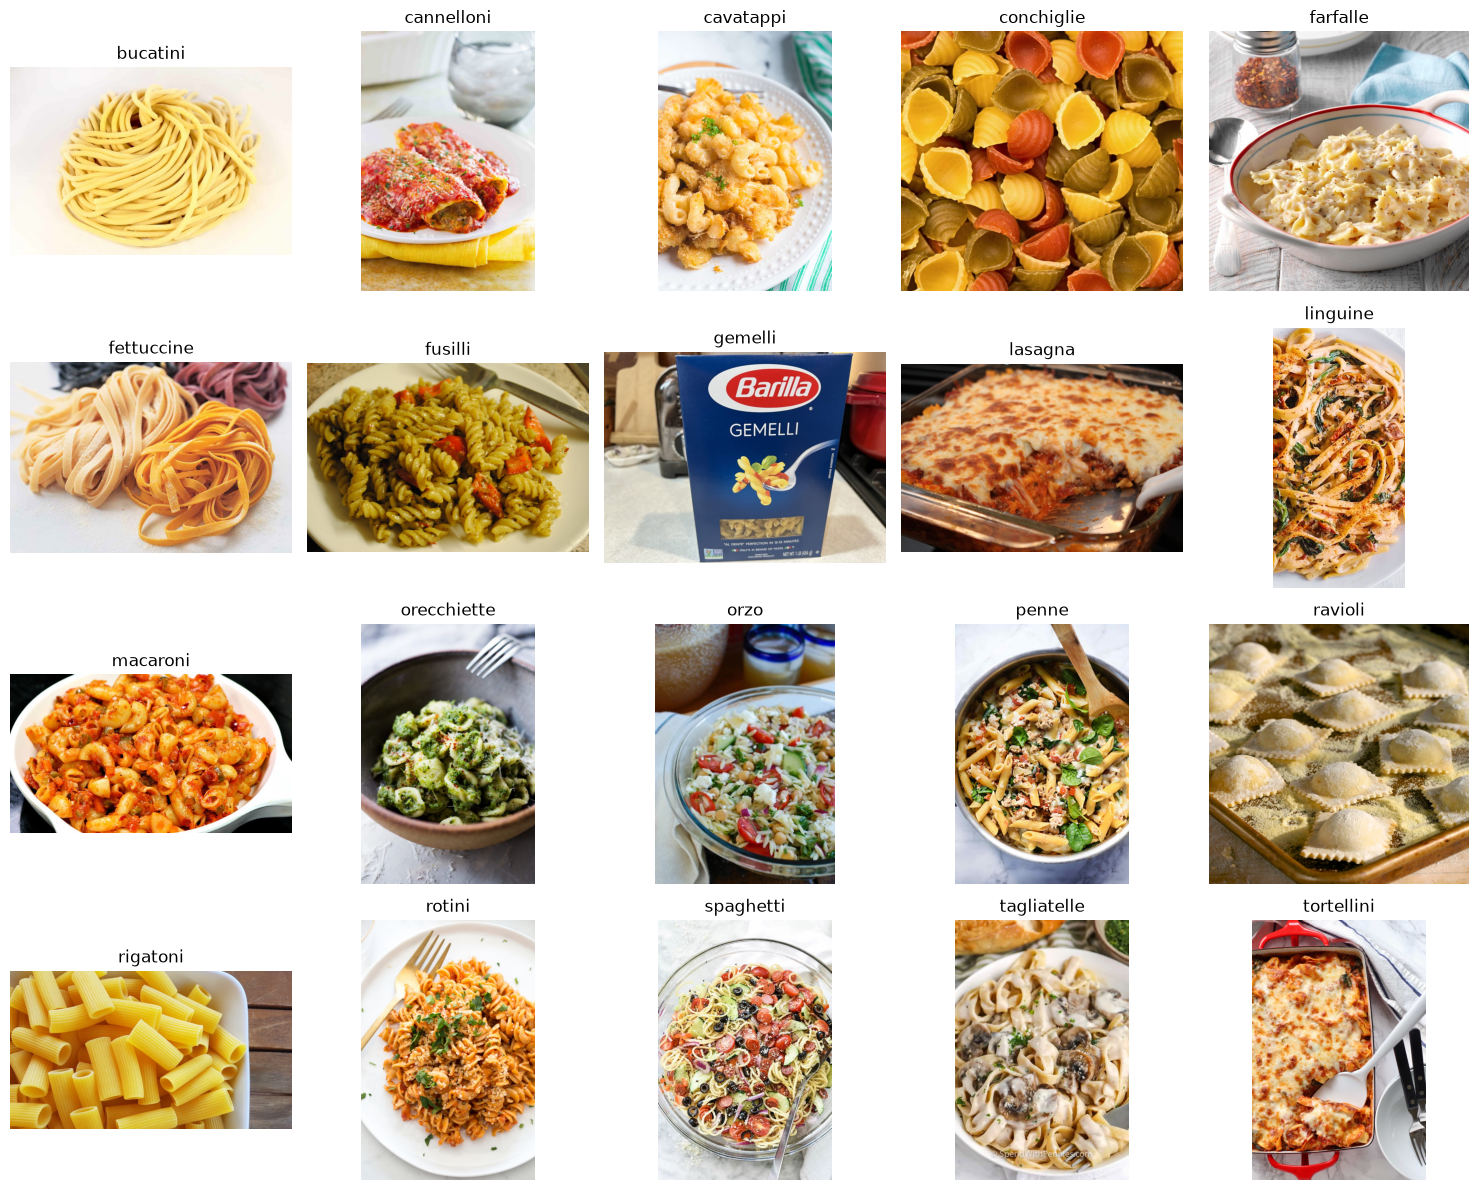

<Figure size 640x480 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for idx, folder in enumerate(sorted(os.listdir(dataset_path))):
    
    # Stop if we have more folders than subplot grid spaces
    if idx >= len(axes):
        break
        
    inner_path = os.path.join(dataset_path, folder, folder) 
    
    if os.path.isdir(inner_path):
        all_files = os.listdir(inner_path)
        valid_images = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        #checks for valid image extension
        if valid_images:
            random_img = random.choice(valid_images)
            img = mpimg.imread(os.path.join(inner_path, random_img))
            
            axes[idx].imshow(img)
            axes[idx].set_title(folder)
            axes[idx].axis('off')

# Hides any remaining empty plots if there are fewer than 20 pasta types
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()                                   #turns axis titles off

plt.tight_layout()            #formattes the images neatly
plt.show()                    #shows the final result

In [6]:
#imporing pytorch and some related libraries for our task
import torch
from torchvision import datasets, transforms  #for image tasks
from torch.utils.data import DataLoader, random_split  #to manage data
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)
np.random.seed(42)
from tqdm import tqdm

In [7]:
#transforms images as neeeded
transform = transforms.Compose([
    transforms.Resize((224, 224)),  #resized images to the same size
    transforms.ToTensor(),          #turns a image into a pytorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])   #normalizing
])
dataset = datasets.ImageFolder(root=dataset_path, transform=transform) #this loader reads folder and truns folder name into class label
print('total images:', len(dataset))
print('Classes:', dataset.classes)

total images: 7288
Classes: ['bucatini', 'cannelloni', 'cavatappi', 'conchiglie', 'farfalle', 'fettuccine', 'fusilli', 'gemelli', 'lasagna', 'linguine', 'macaroni', 'orecchiette', 'orzo', 'penne', 'ravioli', 'rigatoni', 'rotini', 'spaghetti', 'tagliatelle', 'tortellini']


In [8]:
from torch.utils.data import Dataset
from PIL import Image
import os

#faced an issue wth corrupted data i didn't account for prevously. so i added a class that goes through the images and removes corrupted images
class SafeImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform
        self.classes = sorted(os.listdir(root))                        #sorts the classes
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)} #assigns an index

        #kooos through each pasta class
        for label in self.classes:
            inner = os.path.join(root, label, label)
            if not os.path.isdir(inner): #skips if inner folder does not exist
                continue
            for fname in os.listdir(inner):
                path = os.path.join(inner, fname)
                try:
                    img = Image.open(path)                                #tries to open every eage file
                    img.verify()                                          #and verify it
                    self.samples.append((path, self.class_to_idx[label])) #append to the samples folder
                except Exception as e:
                    print(f"Skipping bad image: {path} — {e}")            #if fails to do that, skip the bad image

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

dataset = SafeImageFolder(root=dataset_path, transform=transform)
print(f"Clean dataset size: {len(dataset)}")

Skipping bad image: C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\linguine\linguine\170ddc97-0b62-4ab3-98ae-dfb3e7a5c110.asp — cannot identify image file 'C:\\Users\\User\\.cache\\kagglehub\\datasets\\zibranzarif\\pasta-shape-dataset\\versions\\1\\linguine\\linguine\\170ddc97-0b62-4ab3-98ae-dfb3e7a5c110.asp'
Skipping bad image: C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\linguine\linguine\422f388d-8daa-4066-8399-f0caf6c85601.webp — cannot identify image file 'C:\\Users\\User\\.cache\\kagglehub\\datasets\\zibranzarif\\pasta-shape-dataset\\versions\\1\\linguine\\linguine\\422f388d-8daa-4066-8399-f0caf6c85601.webp'


C:\Users\User\miniconda3\envs\cv_env\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


Clean dataset size: 7302


In [9]:
#basically doing train-test-split hehe
train_size = int(0.70 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #loads train data in batches.
                                                                      #32 images at a time.
                                                                      #shuffles the dataset for training so model doesn't train based on the order of the images

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)  #validation does not require shuffling
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [11]:
print(f"Training images: {train_size}")
print(f"Validation images: {val_size}")
print(f"Test images: {test_size}")

Training images: 5111
Validation images: 1095
Test images: 1096


In [12]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights #from pytorch's vision models, we imported resnet 18

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  #loads ResNet18's pretrained weights as our model as our model
num_ftrs = model.fc.in_features                           #stores how many inputs ResNet's final layer expects (512)
model.fc = nn.Linear(num_ftrs, len(dataset.classes))      #ResNet18 gives output of 1000 ImageNet classes we modify it to the number of pasta shape classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #checks if colab gpu is available
model = model.to(device)

print('using device:', device)

using device: cuda


In [13]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()                    #Loss function. Determines how wrong the model is
optimizer = optim.Adam(model.parameters(), lr=0.001) #decides how the model updates its knowledge

# RUN 01


In [14]:
best_val_acc = 0
best_epoch = 0

epochs = 10     #the whole dataset is 'seen' by the model for 10 times

for epoch in range(epochs):
  model.train()     #training mode on
  train_loss = 0
  correct = 0
  total = 0

  loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}") #progressbar for me :)
  #working on training data first
  for images, labels in loop:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()       #clears old gradients
    outputs = model(images)     #makes predictions
    loss = criterion(outputs, labels)
    #backpropagation
    loss.backward()     #calculates how much wight contributed in the error
    optimizer.step()    #updates model weight
    train_loss += loss.item()
    _, predicted = outputs.max(1)
    correct += predicted.eq(labels).sum().item()
    total += labels.size(0)
    loop.set_postfix(loss=loss.item(), acc=100.*correct/total) #updates progressbar in real-time

  model.eval()    #evaluation mode on
  val_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()
      _, predicted = outputs.max(1)
      val_correct += predicted.eq(labels).sum().item()
      val_total += labels.size(0)

  train_acc = 100.*correct/total
  val_acc = 100.*val_correct/val_total

  if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_run1.pth')

  print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | Best: {best_val_acc:.1f}% (epoch {best_epoch})")


Epoch 1/10:   4%|▍         | 6/160 [00:04<02:04,  1.24it/s, acc=14.1, loss=2.99]C:\Users\User\miniconda3\envs\cv_env\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/10: 100%|██████████| 160/160 [01:46<00:00,  1.50it/s, acc=36.3, loss=1.89]


Epoch 1/10 | Train Acc: 36.3% | Val Acc: 26.8% | Best: 26.8% (epoch 1)


Epoch 2/10: 100%|██████████| 160/160 [01:45<00:00,  1.52it/s, acc=55.4, loss=0.997]


Epoch 2/10 | Train Acc: 55.4% | Val Acc: 44.3% | Best: 44.3% (epoch 2)


Epoch 3/10: 100%|██████████| 160/160 [01:43<00:00,  1.55it/s, acc=68, loss=1.37]   


...

Epoch 8/10 | Train Acc: 91.9% | Val Acc: 45.6% | Best: 67.2% (epoch 7)


Epoch 9/10: 100%|██████████| 160/160 [01:45<00:00,  1.51it/s, acc=93.8, loss=0.179] 


Epoch 9/10 | Train Acc: 93.8% | Val Acc: 58.5% | Best: 67.2% (epoch 7)


Epoch 10/10: 100%|██████████| 160/160 [01:46<00:00,  1.50it/s, acc=93.1, loss=0.267] 


Epoch 10/10 | Train Acc: 93.1% | Val Acc: 59.3% | Best: 67.2% (epoch 7)


In [15]:
model.load_state_dict(torch.load('best_model_run1.pth'))
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_correct += predicted.eq(labels).sum().item()
        test_total += labels.size(0)

print(f"Final Test Accuracy: {100.*test_correct/test_total:.1f}%")

Final Test Accuracy: 70.5%


# RUN 02

In [16]:
#augmentation for training set
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),                                     #flips horizontally
    transforms.RandomRotation(15),                                         #rotates randomly upto 15 degrees
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  #randomly changes brightness, contrast and saturation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),              #shifts the image
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#for validation set only resized, turned into a tensor, and normalized
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [17]:
from torch.utils.data import Subset

#full dataset with no transform
full_dataset = SafeImageFolder(root= dataset_path, transform=None)

#splitting the data
# Replace your current split with this:
train_size = int(0.70 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_indices, val_indices, test_indices = torch.utils.data.random_split(
    range(len(full_dataset)), [train_size, val_size, test_size]
)

# Applying different transforms to each split
class TransformDataset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = TransformDataset(full_dataset, train_indices, train_transform)
val_dataset = TransformDataset(full_dataset, val_indices, val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

test_dataset = TransformDataset(full_dataset, test_indices, val_transform)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Skipping bad image: C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\linguine\linguine\170ddc97-0b62-4ab3-98ae-dfb3e7a5c110.asp — cannot identify image file 'C:\\Users\\User\\.cache\\kagglehub\\datasets\\zibranzarif\\pasta-shape-dataset\\versions\\1\\linguine\\linguine\\170ddc97-0b62-4ab3-98ae-dfb3e7a5c110.asp'
Skipping bad image: C:\Users\User\.cache\kagglehub\datasets\zibranzarif\pasta-shape-dataset\versions\1\linguine\linguine\422f388d-8daa-4066-8399-f0caf6c85601.webp — cannot identify image file 'C:\\Users\\User\\.cache\\kagglehub\\datasets\\zibranzarif\\pasta-shape-dataset\\versions\\1\\linguine\\linguine\\422f388d-8daa-4066-8399-f0caf6c85601.webp'
Train size: 5111
Val size: 1095
Test size: 1096


In [18]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(full_dataset.classes))
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler - reduces lr (learning rate) by half if val accuracy doesn't improve for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print("Model reset and ready!")

Model reset and ready!


In [19]:
best_val_acc = 0
best_epoch = 0

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    train_acc = 100.*correct/total
    val_acc = 100.*val_correct/val_total

    scheduler.step(val_acc)    #tells the scheduler the current val accuracy

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_run2.pth') #saves model weights for the best epoch

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | Best: {best_val_acc:.1f}% (epoch {best_epoch})")

Epoch 1/10: 100%|██████████| 80/80 [01:49<00:00,  1.37s/it, acc=36.3, loss=1.47]


Epoch 1/10 | Train Acc: 36.3% | Val Acc: 26.0% | Best: 26.0% (epoch 1)


Epoch 2/10: 100%|██████████| 80/80 [01:51<00:00,  1.39s/it, acc=50, loss=1.27]   


Epoch 2/10 | Train Acc: 50.0% | Val Acc: 45.2% | Best: 45.2% (epoch 2)


Epoch 3/10: 100%|██████████| 80/80 [01:51<00:00,  1.39s/it, acc=58.6, loss=1.27] 


...

Epoch 8/10 | Train Acc: 84.4% | Val Acc: 68.9% | Best: 68.9% (epoch 8)


Epoch 9/10: 100%|██████████| 80/80 [01:50<00:00,  1.39s/it, acc=85.8, loss=0.43] 


Epoch 9/10 | Train Acc: 85.8% | Val Acc: 73.4% | Best: 73.4% (epoch 9)


Epoch 10/10: 100%|██████████| 80/80 [01:50<00:00,  1.39s/it, acc=87.3, loss=0.548]


Epoch 10/10 | Train Acc: 87.3% | Val Acc: 73.5% | Best: 73.5% (epoch 10)


In [20]:
model.load_state_dict(torch.load('best_model_run2.pth'))
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_correct += predicted.eq(labels).sum().item()
        test_total += labels.size(0)

print(f"Final Test Accuracy: {100.*test_correct/test_total:.1f}%")

Final Test Accuracy: 72.4%


# RUN 03

In [21]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(full_dataset.classes))

#freezes all layers of ResNet18 except layer4(detects high level features, obejct specific) and fc (final decision layer)
#other layers are universal, no need to relearn that
for name, param in model.named_parameters():
    if not any(x in name for x in ['layer4', 'fc']):
        param.requires_grad = False

model = model.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001) #only passes unfrozen parameters
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) #checks how many parameters are trainable
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Trainable parameters: 8,403,988 / 11,186,772


In [22]:
#revised augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = TransformDataset(full_dataset, train_indices, train_transform)
val_dataset = TransformDataset(full_dataset, val_indices, val_transform)
test_dataset = TransformDataset(full_dataset, test_indices, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Dataloaders ready!")

Dataloaders ready!


In [23]:
best_val_acc = 0
best_epoch = 0

epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    train_acc = 100.*correct/total
    val_acc = 100.*val_correct/val_total

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_run3.pth')

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | Best: {best_val_acc:.1f}% (epoch {best_epoch})")

Epoch 1/20: 100%|██████████| 160/160 [01:45<00:00,  1.52it/s, acc=43.4, loss=1.89] 


Epoch 1/20 | Train Acc: 43.4% | Val Acc: 55.5% | Best: 55.5% (epoch 1)


Epoch 2/20: 100%|██████████| 160/160 [01:45<00:00,  1.52it/s, acc=60.6, loss=1.5]  


Epoch 2/20 | Train Acc: 60.6% | Val Acc: 58.9% | Best: 58.9% (epoch 2)


Epoch 3/20: 100%|██████████| 160/160 [01:43<00:00,  1.55it/s, acc=68.1, loss=0.729]


...

Epoch 18/20 | Train Acc: 97.6% | Val Acc: 77.4% | Best: 77.4% (epoch 18)


Epoch 19/20: 100%|██████████| 160/160 [01:43<00:00,  1.55it/s, acc=98.5, loss=0.0508] 


Epoch 19/20 | Train Acc: 98.5% | Val Acc: 78.2% | Best: 78.2% (epoch 19)


Epoch 20/20: 100%|██████████| 160/160 [01:43<00:00,  1.55it/s, acc=98.5, loss=0.0407] 


Epoch 20/20 | Train Acc: 98.5% | Val Acc: 78.6% | Best: 78.6% (epoch 20)


In [24]:
model.load_state_dict(torch.load('best_model_run3.pth'))
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_correct += predicted.eq(labels).sum().item()
        test_total += labels.size(0)

print(f"Final Test Accuracy: {100.*test_correct/test_total:.1f}%")

Final Test Accuracy: 78.0%


C:\Users\User\miniconda3\envs\cv_env\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


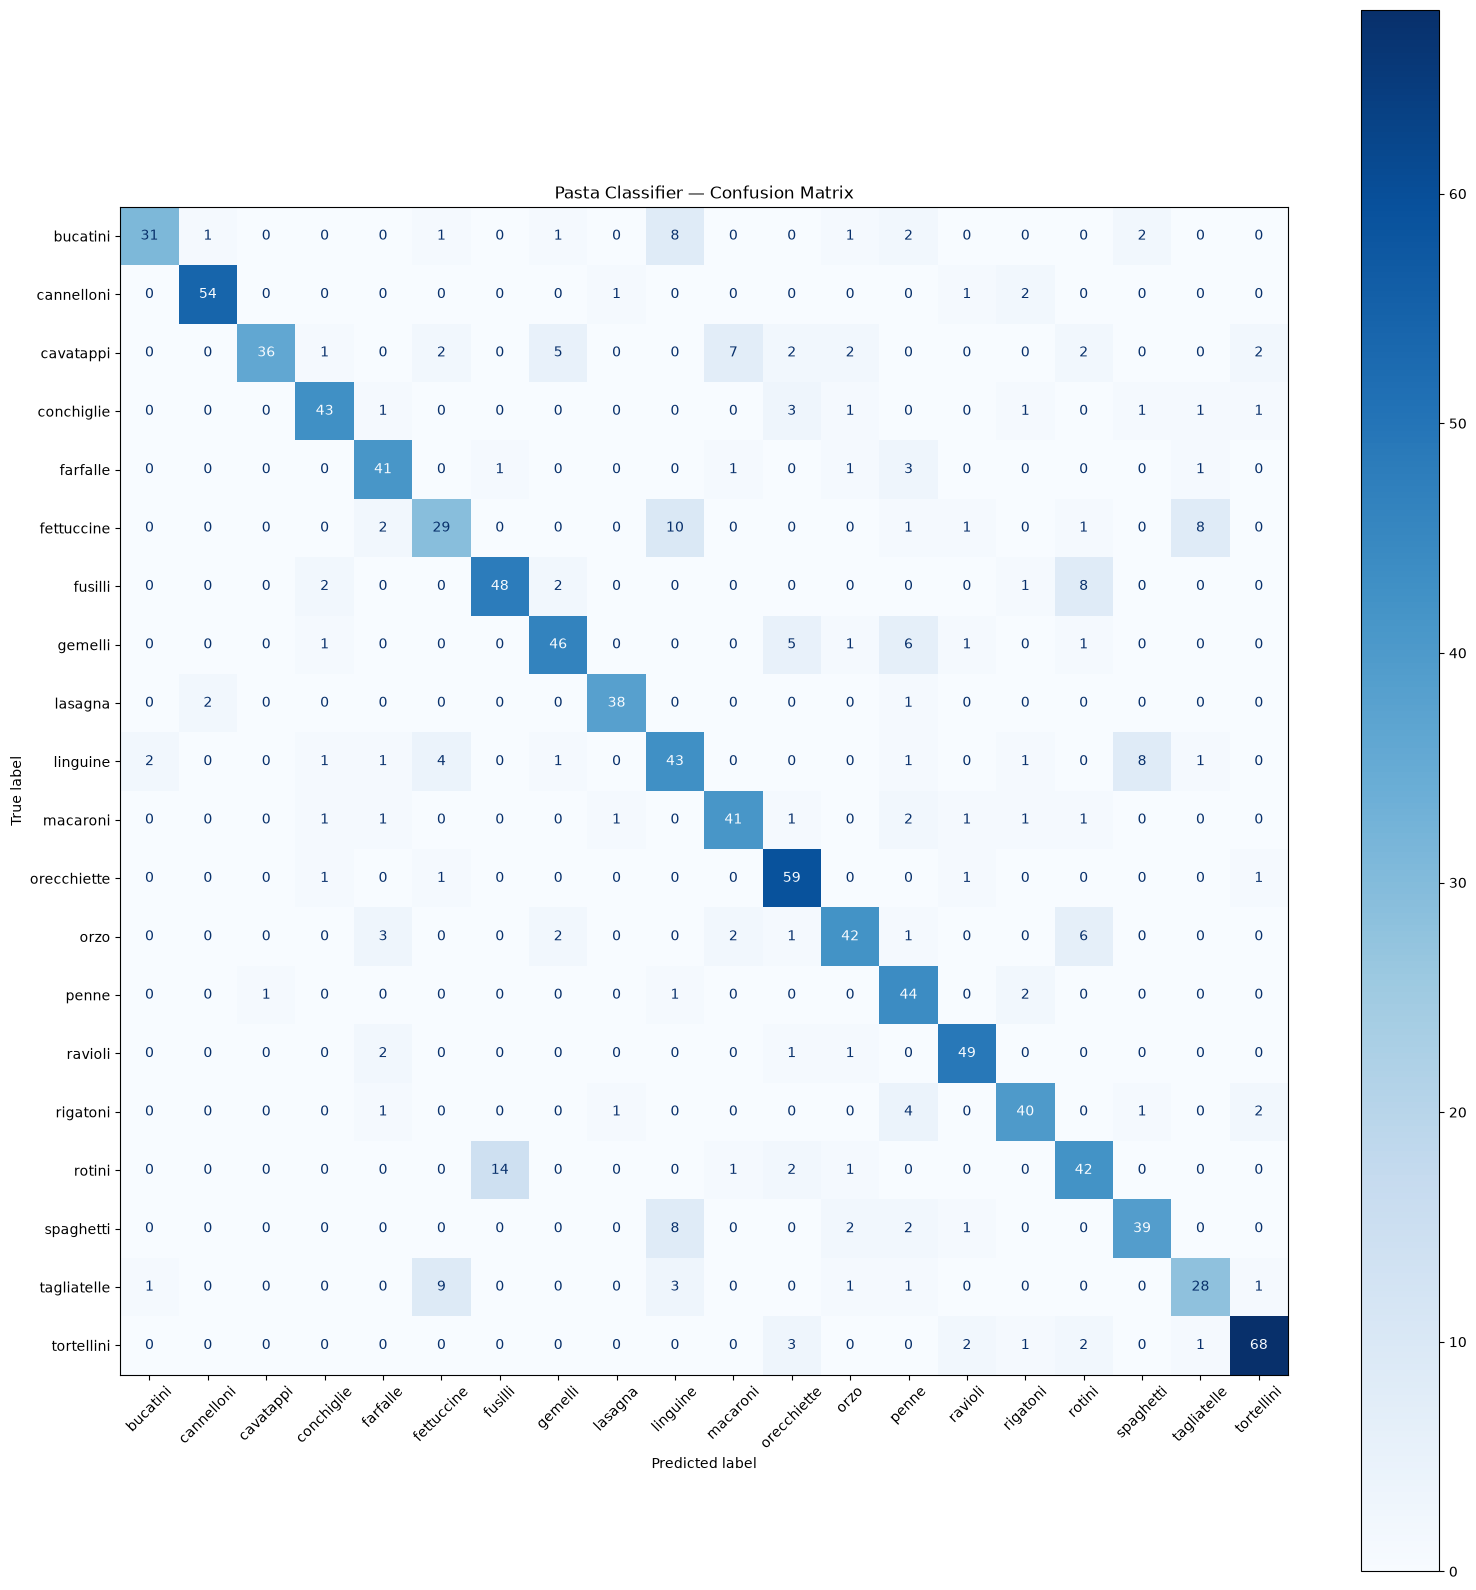

In [25]:
#implementing confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get all predictions on validation set
model.eval()
all_preds = []
all_labels = []


with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#plotting the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(16, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title("Pasta Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()



🍝 Pasta Classifier Results:
------------------------------
#1 farfalle: 99.6%
#2 orzo: 0.3%
#3 gemelli: 0.1%


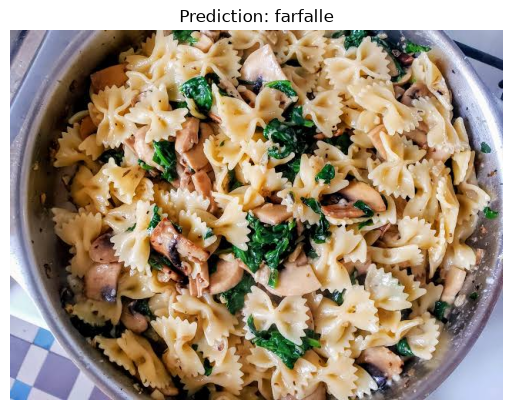

In [29]:
from PIL import Image
import torch.nn.functional as F

#Load best saved model
model.load_state_dict(torch.load('best_model_run3.pth'))
model.eval()

# Upload an image
img_path = "image-1.jpg"

#Open the image file and turn into a tensor
img = Image.open(img_path).convert("RGB")
img_tensor = val_transform(img).unsqueeze(0).to(device)

#Predict
with torch.no_grad():
    outputs = model(img_tensor)
    probs = F.softmax(outputs, dim=1)
    top3_probs, top3_indices = torch.topk(probs, 3)

#Show results
print("\n🍝 Pasta Classifier Results:")
print("-" * 30)
for i in range(3):
    class_name = full_dataset.classes[top3_indices[0][i]]
    probability = top3_probs[0][i].item() * 100
    print(f"#{i+1} {class_name}: {probability:.1f}%")

#Show the image
plt.imshow(Image.open(img_path))
plt.title(f"Prediction: {full_dataset.classes[top3_indices[0][0]]}")
plt.axis('off')
plt.show()

In [30]:
pip install grad-cam

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ---- ----------------------------------- 0.8/7.8 MB 4.8 MB/s eta 0:00:02
     --------- ------------------------------ 1.8/7.8 MB 5.3 MB/s eta 0:00:02
     ---------- ----------------------------- 2.1/7.8 MB 4.2 MB/s eta 0:00:02
     ------------- -------------------------- 2.6/7.8 MB 3.4 MB/s eta 0:00:02
     ----------------- ---------------------- 3.4/7.8 MB 3.2 MB/s eta 0:00:02
     ---------------------- ----------------- 4.5/7.8 MB 3.6 MB/s eta 0:00:01
     ---------------------------- ----------- 5.5/7.8 MB 3.9 MB/s eta 0:00:01
     ----------------------------------- ---- 6.8/7.8 MB 4.1 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 4.3 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing me

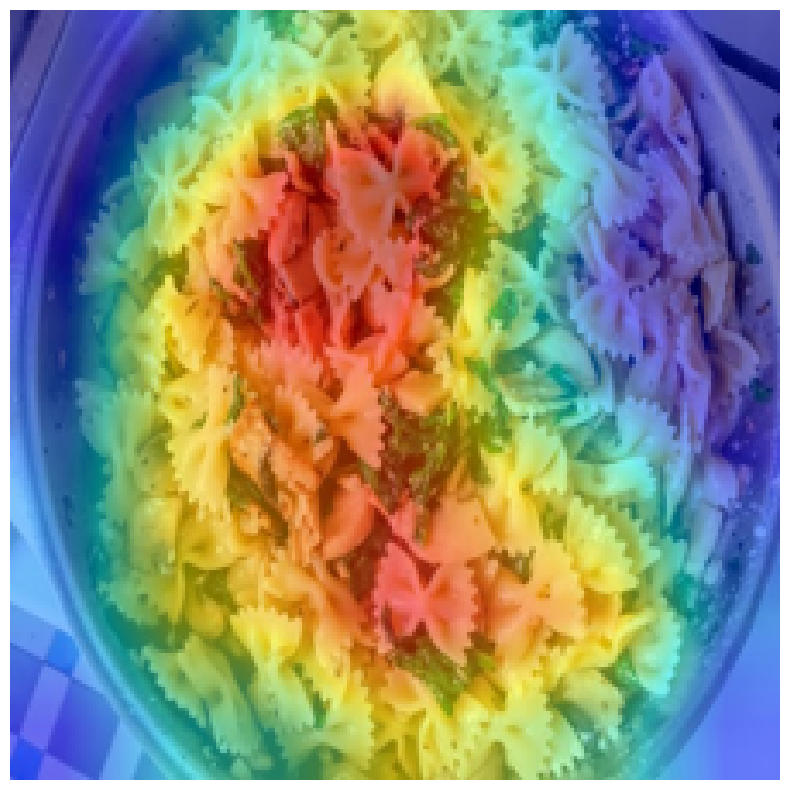

In [32]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

model.load_state_dict(torch.load('best_model_run3.pth'))
model.eval()

# Upload an image
img_path = "image-1.jpg"

#Open the image file and turn into a tensor
img = Image.open(img_path).convert("RGB")
img_tensor = val_transform(img).unsqueeze(0).to(device)

img_resized = img.resize((224, 224))
rgb_img = np.float32(img_resized) / 255.0

# 4. Run Grad-CAM
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)
targets = None

# FIXED: Changed input_tensor to img_tensor
grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :]

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 10))
plt.imshow(visualization)
plt.axis('off')
plt.show()